# 二阶龙格-库塔法（RK2）求解大振幅单摆

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学
- 2026年9月22日

例 3 中 RK2 求解自由落体**精确到机器精度**，上一例的简谐振子更把能量漂移律解析导出——但线性是特权，非线性才是常态。本例用更一般的非线性系统——大振幅单摆——动手检验 RK2 的实战表现。

单摆的运动方程（$\theta$ 为摆线与竖直方向夹角）：

$$
\ddot{\theta} = -\frac{g}{L}\sin\theta
\qquad\Longleftrightarrow\qquad
\frac{d\theta}{dt} = \omega, \quad \frac{d\omega}{dt} = -\frac{g}{L}\sin\theta
$$

右端含 $\sin\theta$，是**非线性**方程，无初等函数表示的封闭解；高精度参考解用 RK45 数值积分（`scipy`）。大振幅的本质效应是周期随振幅增大（$\theta_0 = 120°$ 时 $T/T_0 \approx 1.37$），精确周期由第一类完全椭圆积分给出。

**总机械能**（取最低点为势能零点）

$$
E = \tfrac{1}{2}mL^2\omega^2 + mgL(1 - \cos\theta)
$$

在真实运动中严格守恒；速度相空间中，分界线 $E = 2mgL$ 把**摆动区**（往复）与**旋转区**（绕轴转圈）分开。

**RK2（中点形式）**：先走半步到中点、估出中点斜率，再用它走整步——每步计算**两次**右端。代入单摆：

$$
\omega_{n+\frac{1}{2}} = \omega_n - \tfrac{h}{2}\tfrac{g}{L}\sin\theta_n, \qquad
\theta_{n+\frac{1}{2}} = \theta_n + \tfrac{h}{2}\,\omega_n
$$

$$
\theta_{n+1} = \theta_n + h\,\omega_{n+\frac{1}{2}}, \qquad
\omega_{n+1} = \omega_n - h\,\tfrac{g}{L}\sin\theta_{n+\frac{1}{2}}
$$

**运行之前，先把你的预测写下来**：

1. 自由落体中 RK2 恰好精确；单摆的力（$-\tfrac{g}{L}\sin\theta$）随状态变化——RK2 还精确吗？若不，误差在什么量级？
2. 同一步长下，RK2 的能量漂移比欧拉法快还是慢？
3. 步长减半，RK2 的误差变为几分之一？

带着预测运行下面的代码，逐条对照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.integrate import solve_ivp
from scipy.special import ellipk

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler_pendulum(theta0, omega0, g, L, h, n_steps):
    """前向欧拉法求解单摆 dtheta/dt = omega, domega/dt = -(g/L) sin(theta)
    返回时间、角度、角速度数组（长度 n_steps + 1）"""
    t = np.arange(n_steps + 1) * h
    theta = np.empty(n_steps + 1)
    omega = np.empty(n_steps + 1)
    theta[0], omega[0] = theta0, omega0
    for n in range(n_steps):
        omega[n + 1] = omega[n] - h * (g / L) * np.sin(theta[n])
        theta[n + 1] = theta[n] + h * omega[n]
    return t, theta, omega


def rk2_midpoint_pendulum(theta0, omega0, g, L, h, n_steps):
    """RK2 中点法求解单摆：半步预估中点状态，再用中点斜率走整步"""
    t = np.arange(n_steps + 1) * h
    theta = np.empty(n_steps + 1)
    omega = np.empty(n_steps + 1)
    theta[0], omega[0] = theta0, omega0
    for n in range(n_steps):
        om_mid = omega[n] - 0.5 * h * (g / L) * np.sin(theta[n])   # 中点角速度
        th_mid = theta[n] + 0.5 * h * omega[n]                     # 中点摆角
        theta[n + 1] = theta[n] + h * om_mid                       # 用中点斜率走整步
        omega[n + 1] = omega[n] - h * (g / L) * np.sin(th_mid)
    return t, theta, omega


def reference_solution(theta0, omega0, g, L, t_end):
    """高精度参考解（RK45, rtol=1e-11），返回 dense_output 对象"""
    sol = solve_ivp(
        lambda t, y: [y[1], -(g / L) * np.sin(y[0])],
        [0.0, t_end], [theta0, omega0],
        method='RK45', rtol=1e-11, atol=1e-12, dense_output=True
    )
    return sol


# 参数（大振幅标准算例）
theta0 = np.deg2rad(120.0)   # 初始摆角 (rad)，大振幅
omega0 = 0.0                 # 初始角速度 (rad/s)
m = 1.0                      # 摆球质量 (kg)
L = 1.0                      # 摆长 (m)
g = 9.8                      # 重力加速度 (m/s^2)
h = 0.002                    # 时间步长 (s)
t_end = 10.0                 # 总时间 (s)
om0 = np.sqrt(g / L)         # 小角频率
T0 = 2 * np.pi / om0         # 小角周期
T_exact = 4 * np.sqrt(L / g) * ellipk(np.sin(theta0 / 2)**2)

t, theta_euler, omg_euler = forward_euler_pendulum(theta0, omega0, g, L, h, int(t_end / h))
t, theta_rk2, omg_rk2 = rk2_midpoint_pendulum(theta0, omega0, g, L, h, int(t_end / h))
ref = reference_solution(theta0, omega0, g, L, t_end)
theta_ref, omega_ref = ref.sol(t)
theta_sa = theta0 * np.cos(om0 * t)   # 小角近似

# 总机械能：E = 1/2 m L^2 omega^2 + m g L (1 - cos(theta))
E_euler = 0.5 * m * L**2 * omg_euler**2 + m * g * L * (1 - np.cos(theta_euler))
E_rk2   = 0.5 * m * L**2 * omg_rk2**2 + m * g * L * (1 - np.cos(theta_rk2))
E0 = 0.5 * m * L**2 * omega0**2 + m * g * L * (1 - np.cos(theta0))
E_sep = 2 * m * g * L                 # 分界线能量

err_theta_euler = theta_euler - theta_ref
err_theta_rk2   = theta_rk2 - theta_ref

print(f'小角周期 T0 = {T0:.4f} s；θ0 = 120° 精确周期 T = {T_exact:.4f} s（T/T0 = {T_exact / T0:.4f}）')
print(f'初始能量 E0 = {E0:.4f} J；分界线能量 E = 2mgL = {E_sep:.4f} J')
print(f'\n{"":12}{"RK2":>16}{"前向欧拉":>16}')
print(f'{"末能量漂移 (J)":12}{E_rk2[-1] - E0:>16.3e}{E_euler[-1] - E0:>16.3e}')
print(f'{"相对漂移":12}{100 * (E_rk2[-1] - E0) / E0:>15.2e}%{100 * (E_euler[-1] - E0) / E0:>14.2e}%')
print(f'{"末摆角误差 (rad)":14}{err_theta_rk2[-1]:>12.3e}{err_theta_euler[-1]:>16.3e}')

小角周期 T0 = 2.0071 s；θ0 = 120° 精确周期 T = 2.7555 s（T/T0 = 1.3729）
初始能量 E0 = 14.7000 J；分界线能量 E = 2mgL = 19.6000 J

                         RK2            前向欧拉
末能量漂移 (J)          1.267e-05       1.325e+00
相对漂移               8.62e-05%      9.02e+00%
末摆角误差 (rad)      3.217e-05      -7.127e-01


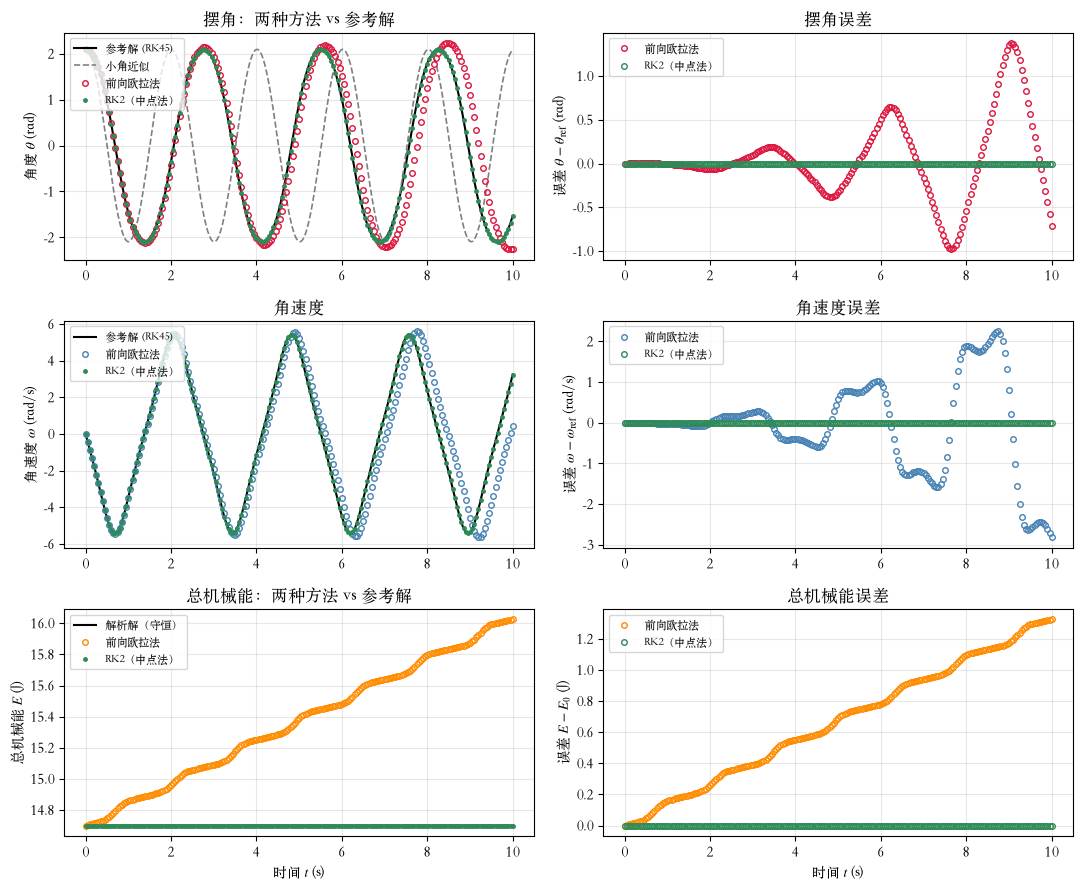

In [3]:
fig, axs = plt.subplots(3, 2, figsize=(11, 9))

# 左列：数值解 vs 参考解（两种方法）
ax = axs[0, 0]
ax.plot(t, theta_ref, 'k-', lw=1.5, label='参考解 (RK45)')
ax.plot(t, theta_sa, '--', color='gray', lw=1.2, label='小角近似')
ax.plot(t, theta_euler, 'o', ms=4, mfc='none', color='crimson', label='前向欧拉法', markevery=25)
ax.plot(t, theta_rk2, '.', ms=5, color='seagreen', label='RK2（中点法）', markevery=25)
ax.set_ylabel('角度 $\\theta$ (rad)')
ax.set_title('摆角：两种方法 vs 参考解')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

ax = axs[1, 0]
ax.plot(t, omega_ref, 'k-', lw=1.5, label='参考解 (RK45)')
ax.plot(t, omg_euler, 'o', ms=4, mfc='none', color='steelblue', label='前向欧拉法', markevery=25)
ax.plot(t, omg_rk2, '.', ms=5, color='seagreen', label='RK2（中点法）', markevery=25)
ax.set_ylabel('角速度 $\\omega$ (rad/s)')
ax.set_title('角速度')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

ax = axs[2, 0]
ax.plot(t, np.full_like(t, E0), 'k-', lw=1.5, label='解析解（守恒）')
ax.plot(t, E_euler, 'o', ms=4, mfc='none', color='darkorange', label='前向欧拉法', markevery=25)
ax.plot(t, E_rk2, '.', ms=5, color='seagreen', label='RK2（中点法）', markevery=25)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总机械能 $E$ (J)')
ax.set_title('总机械能：两种方法 vs 参考解')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# 右列：对应的误差（带符号）
ax = axs[0, 1]
ax.plot(t, err_theta_euler, 'o', ms=4, mfc='none', color='crimson', markevery=25, label='前向欧拉法')
ax.plot(t, err_theta_rk2, 'o', ms=4, mfc='none', color='seagreen', markevery=25, label='RK2（中点法）')
ax.set_ylabel('误差 $\\theta - \\theta_{\\mathrm{ref}}$ (rad)')
ax.set_title('摆角误差')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axs[1, 1]
ax.plot(t, omg_euler - omega_ref, 'o', ms=4, mfc='none', color='steelblue', markevery=25, label='前向欧拉法')
ax.plot(t, omg_rk2 - omega_ref, 'o', ms=4, mfc='none', color='seagreen', markevery=25, label='RK2（中点法）')
ax.set_ylabel('误差 $\\omega - \\omega_{\\mathrm{ref}}$ (rad/s)')
ax.set_title('角速度误差')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axs[2, 1]
ax.plot(t, E_euler - E0, 'o', ms=4, mfc='none', color='darkorange', markevery=25, label='前向欧拉法')
ax.plot(t, E_rk2 - E0, 'o', ms=4, mfc='none', color='seagreen', markevery=25, label='RK2（中点法）')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('误差 $E - E_0$ (J)')
ax.set_title('总机械能误差')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/5_simple_pendulum_rk2_main.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

**对照预测 1–3**：

- **不再精确**：RK2 与参考解的差别在误差面板中清晰可见——力随 $\theta$ 变化后，中点斜率不再是步内的"平均斜率"，每一小步都留下误差。这正是例 3 思考①的答案：**"恰好精确"是常力问题的特例，不是 RK2 的一般性质。**
- **但精度高得多**：同一步长 $h = 0.002$ s 下，末摆角误差 RK2 $\sim 3\times 10^{-5}$ rad vs 欧拉 $\sim 0.7$ rad；末能量漂移 $\sim 10^{-5}$ J（$0.0001\%$）vs $\sim 1.3$ J（$9\%$）——四五个数量级的差距。
- **漂移回来了**：RK2 的能量不再停在机器精度，而是随时间缓慢爬升——这是**方法误差**（下面用收敛性分析量化它随 $h$ 的阶数），不是舍入噪声。它随时间无界增长，会带来什么物理后果？本例最后一节见分晓。

## 速度相空间：谁向外螺旋更快？

真实单摆沿等能线闭合运动；欧拉解不断穿越等能线向外螺旋。把两种方法各跑 30 s（约 11 个周期）画进速度相空间 $(\theta, \omega)$，欧拉的线色随时间变化（色条）：**RK2 的螺旋还看得见吗？谁注能更快？**

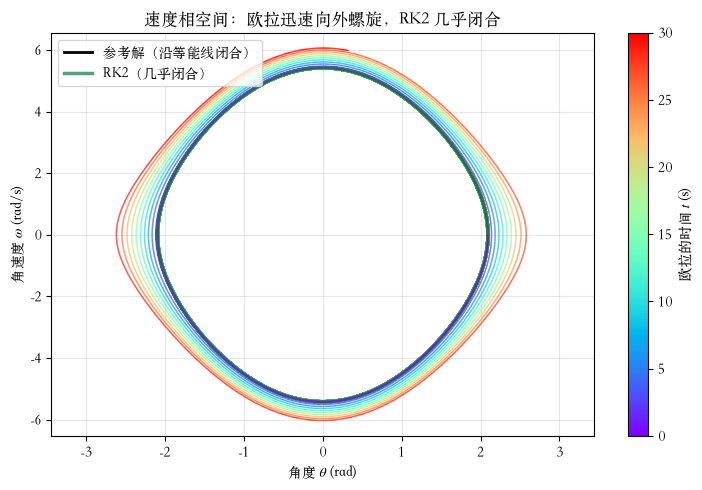

In [4]:
# 速度相空间轨迹（30 s ≈ 11 个周期）：参考解 vs 两种数值方法
t_s, theta_es, omg_es = forward_euler_pendulum(theta0, omega0, g, L, h, int(30.0 / h))
_,  theta_rs, omg_rs = rk2_midpoint_pendulum(theta0, omega0, g, L, h, int(30.0 / h))

fig, ax = plt.subplots(figsize=(7.5, 5))

# 参考解：沿等能线闭合（画一个周期即可）
t_orb = np.linspace(0.0, T_exact, 400)
th_orb, om_orb = ref.sol(t_orb)
ax.plot(th_orb, om_orb, 'k-', lw=2, label='参考解（沿等能线闭合）')

# RK2：几乎与参考解重合（30 s 内漂移仅 ~1e-4 J）
ax.plot(theta_rs, omg_rs, '-', color='seagreen', lw=2.5, alpha=0.8,
        label='RK2（几乎闭合）')

# 前向欧拉：线色随时间变化，向外螺旋
points = np.array([theta_es, omg_es]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='rainbow', array=t_s, lw=1.0)
ax.add_collection(lc)
cbar = fig.colorbar(lc, ax=ax)
cbar.set_label('欧拉的时间 $t$ (s)')

ax.set_xlabel('角度 $\\theta$ (rad)')
ax.set_ylabel('角速度 $\\omega$ (rad/s)')
ax.set_xlim(-np.pi - 0.3, np.pi + 0.3)
ax.set_ylim(omg_es.min() - 0.5, omg_es.max() + 0.5)
ax.set_title('速度相空间：欧拉迅速向外螺旋，RK2 几乎闭合')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/5_simple_pendulum_rk2_phase.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 为什么不再精确

- **常力 vs 变力**：自由落体的加速度 $g$ 是常量，速度在步内线性变化，中点速度恰为区间平均速度——中点法"碰巧"精确。单摆的角加速度 $-\tfrac{g}{L}\sin\theta$ 依赖当前状态、随时间变化，中点斜率不再是步内平均斜率，每步留下 $\mathcal{O}(h^3)$ 的局部截断误差。
- **全局误差 $\mathcal{O}(h^2)$**：每步局部误差 $\mathcal{O}(h^3)$，累积 $t/h$ 步，全局误差 $\mathcal{O}(h^2)$——这就是"二阶方法"的含义：步长减半，误差变为约 $1/4$（下面验证）。
- **能量漂移回归**：动能–势能转换出现系统性盈余，$E_n$ 缓慢爬升。对振荡系统可以证明 RK2 的能量增长率 $\propto h^3$（欧拉为 $\propto h$）：同一步长下慢得多，但**同样无界**。

| | 自由落体（常力） | 大振幅单摆（变力） |
| :-- | :-- | :-- |
| RK2 是否精确 | 恰好精确（机器精度） | 不精确，全局误差 $\mathcal{O}(h^2)$ |
| 能量漂移 | 仅舍入水平（$\sim 10^{-13}$ J） | 方法误差 $\propto h^3\,t$（本例 $\sim 10^{-5}$ J） |

## 收敛性分析：二阶到底有多快

固定问题，把步长从粗到细扫描，看误差怎么降。用两张"成绩单"：

- **周期误差**（小振幅 $\theta_0 = 10°$，数值周期由过零点测出，精确值由椭圆积分给出）——单摆最敏感的可观测量；
- **末时刻能量漂移**（$\theta_0 = 120°$、$t = 10$ s）——漂移随时间单调增长，是最干净的收敛标尺（末摆角误差会因相位错开而"绕圈"，不适合做判据）。

**先预测，再运行**：欧拉的误差 $\propto h$（斜率 1）。RK2 的两条误差曲线各是什么斜率？步长减半，误差各变为几分之一？

A. 周期误差（θ0 = 10°，精确值 T = 2.010918 s）
    h (s)     欧拉|ΔT| (s)      减半比    RK2|ΔT| (s)      减半比
  0.02000      2.498e-02       --      1.297e-03       --
  0.01000      6.033e-03     4.14      3.254e-04     3.99
  0.00500      2.142e-03     2.82      8.147e-05     3.99
  0.00250      9.008e-04     2.38      2.038e-05     4.00
  0.00125      4.124e-04     2.18      5.096e-06     4.00

B. 末时刻能量漂移（θ0 = 120°，t = 10 s）
    h (s)     欧拉|ΔE| (J)      减半比    RK2|ΔE| (J)      减半比
  0.04000      2.021e+01       --      6.577e-02       --
  0.02000      9.202e+00     2.20      8.512e-03     7.73
  0.01000      5.460e+00     1.69      1.123e-03     7.58
  0.00500      3.236e+00     1.69      1.548e-04     7.25
  0.00250      1.652e+00     1.96      2.295e-05     6.75


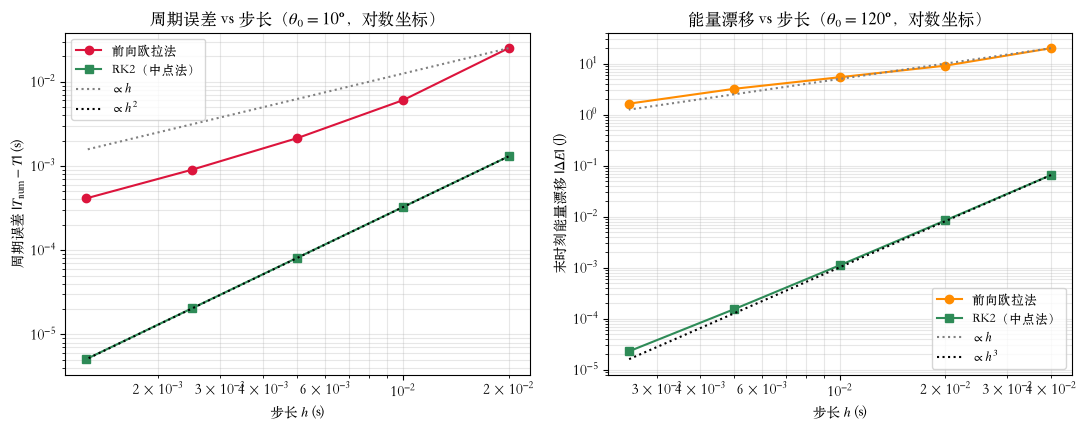

In [5]:
def measure_period(solver, th0, h_i):
    """过零点法测数值周期（线性插值），返回 T 或 NaN（轨迹发散时）"""
    t_max = 8 * T0
    _, th_i, _ = solver(th0, 0.0, g, L, h_i, int(t_max / h_i))
    idx = np.where(np.diff(np.sign(th_i)) != 0)[0]
    if len(idx) < 4:
        return np.nan
    tt = np.arange(len(th_i)) * h_i
    t_cross = tt[idx] + h_i * np.abs(th_i[idx]) / (np.abs(th_i[idx]) + np.abs(th_i[idx + 1]))
    return 2.0 * np.mean(np.diff(t_cross))


h_list_p = [0.02, 0.01, 0.005, 0.0025, 0.00125]          # 周期误差扫描
h_list_E = [0.04, 0.02, 0.01, 0.005, 0.0025]             # 能量漂移扫描

# --- A：小振幅周期误差 ---
th0_small = np.deg2rad(10.0)
T_ex_small = 4 * np.sqrt(L / g) * ellipk(np.sin(th0_small / 2)**2)

T_err_e, T_err_r = [], []
print('A. 周期误差（θ0 = 10°，精确值 T = %.6f s）' % T_ex_small)
print(f'{"h (s)":>9}{"欧拉|ΔT| (s)":>15}{"减半比":>9}{"RK2|ΔT| (s)":>15}{"减半比":>9}')
for h_i in h_list_p:
    e_i = abs(measure_period(forward_euler_pendulum, th0_small, h_i) - T_ex_small)
    r_i = abs(measure_period(rk2_midpoint_pendulum, th0_small, h_i) - T_ex_small)
    T_err_e.append(e_i); T_err_r.append(r_i)
    re_ = f'{T_err_e[-2] / e_i:.2f}' if len(T_err_e) > 1 else '--'
    rr_ = f'{T_err_r[-2] / r_i:.2f}' if len(T_err_r) > 1 else '--'
    print(f'{h_i:>9.5f}{e_i:>15.3e}{re_:>9}{r_i:>15.3e}{rr_:>9}')

# --- B：末时刻能量漂移（θ0 = 120°，t = 10 s） ---
E_drift_e, E_drift_r = [], []
print('\nB. 末时刻能量漂移（θ0 = 120°，t = 10 s）')
print(f'{"h (s)":>9}{"欧拉|ΔE| (J)":>15}{"减半比":>9}{"RK2|ΔE| (J)":>15}{"减半比":>9}')
for h_i in h_list_E:
    _, te_i, oe_i = forward_euler_pendulum(theta0, omega0, g, L, h_i, int(t_end / h_i))
    _, tr_i, orr_i = rk2_midpoint_pendulum(theta0, omega0, g, L, h_i, int(t_end / h_i))
    e_i = abs(0.5 * m * L**2 * oe_i[-1]**2 + m * g * L * (1 - np.cos(te_i[-1])) - E0)
    r_i = abs(0.5 * m * L**2 * orr_i[-1]**2 + m * g * L * (1 - np.cos(tr_i[-1])) - E0)
    E_drift_e.append(e_i); E_drift_r.append(r_i)
    re_ = f'{E_drift_e[-2] / e_i:.2f}' if len(E_drift_e) > 1 else '--'
    rr_ = f'{E_drift_r[-2] / r_i:.2f}' if len(E_drift_r) > 1 else '--'
    print(f'{h_i:>9.5f}{e_i:>15.3e}{re_:>9}{r_i:>15.3e}{rr_:>9}')

# --- 作图 ---
floor = 1e-18
h_p = np.array(h_list_p)
h_E = np.array(h_list_E)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))

ax1.loglog(h_p, np.maximum(T_err_e, floor), 'o-', color='crimson', label='前向欧拉法')
ax1.loglog(h_p, np.maximum(T_err_r, floor), 's-', color='seagreen', label='RK2（中点法）')
ax1.loglog(h_p, T_err_e[0] * h_p / h_p[0], ':', color='gray', label='$\\propto h$')
ax1.loglog(h_p, T_err_r[0] * (h_p / h_p[0])**2, ':', color='black', label='$\\propto h^2$')
ax1.set_xlabel('步长 $h$ (s)')
ax1.set_ylabel('周期误差 $|T_{\\mathrm{num}} - T|$ (s)')
ax1.set_title('周期误差 vs 步长（$\\theta_0 = 10°$，对数坐标）')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3, which='both')

ax2.loglog(h_E, np.maximum(E_drift_e, floor), 'o-', color='darkorange', label='前向欧拉法')
ax2.loglog(h_E, np.maximum(E_drift_r, floor), 's-', color='seagreen', label='RK2（中点法）')
ax2.loglog(h_E, E_drift_e[0] * h_E / h_E[0], ':', color='gray', label='$\\propto h$')
ax2.loglog(h_E, E_drift_r[0] * (h_E / h_E[0])**3, ':', color='black', label='$\\propto h^3$')
ax2.set_xlabel('步长 $h$ (s)')
ax2.set_ylabel('末时刻能量漂移 $|\\Delta E|$ (J)')
ax2.set_title('能量漂移 vs 步长（$\\theta_0 = 120°$，对数坐标）')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig('outputs/5_simple_pendulum_rk2_convergence.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

**读图**：

- **周期误差**（左图）：RK2 严格沿 $\propto h^2$ 参考线下降——减半比恒为 $4.0$；欧拉渐近 $\propto h$（减半比趋于 $2$）。二阶名副其实。
- **能量漂移**（右图）：RK2 沿 $\propto h^3$ 参考线（减半比 $\approx 8$），欧拉只有 $\propto h$——每步多算的那一次右端，把漂移率从一阶压到三阶。
- 但注意：两条 RK2 曲线斜率再陡，**高度也不为零**。漂移仍在、仍随时间无界增长——下一步看它的物理后果。

## 长时间模拟：漂移的物理后果——摆被"注"进旋转区

能量爬升不是抽象的数字游戏。速度相空间里，分界线 $E = 2mgL$ 把**摆动**（往复）与**旋转**（绕轴转圈）分开：能量一旦越过它，单摆的定性行为就改变。

换上"放大镜"步长 $h = 0.1$ s（在两方法的线性稳定界限 $h < 2\sqrt{L/g} \approx 0.64$ s 之内），模拟 200 s。

**先预测，再运行**：

1. 能量持续增长的数值解，它的"单摆"会怎样？
2. 欧拉与 RK2 各在什么时候越过分界线？相差多少倍？

前向欧拉法：t = 0.8 s 越过分界线 E = 2mgL（初始 E0 = 14.7 J）
RK2（中点法）：t = 51.7 s 越过分界线 E = 2mgL（初始 E0 = 14.7 J）


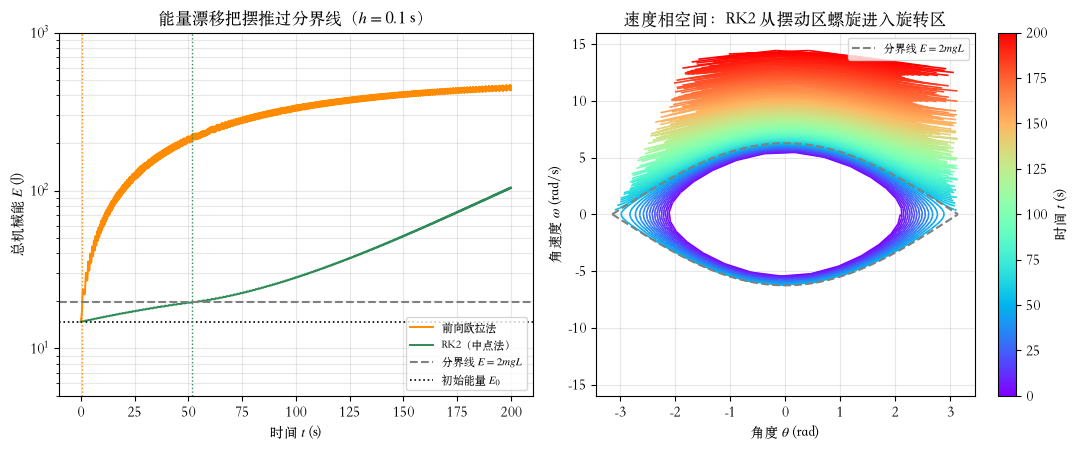

In [6]:
h_long = 0.1                    # 放大镜步长 (s)
t_long = 200.0                  # 总时间 (s)
n_long = int(t_long / h_long)

t_L, theta_eL, omg_eL = forward_euler_pendulum(theta0, omega0, g, L, h_long, n_long)
t_L, theta_rL, omg_rL = rk2_midpoint_pendulum(theta0, omega0, g, L, h_long, n_long)

E_eL = 0.5 * m * L**2 * omg_eL**2 + m * g * L * (1 - np.cos(theta_eL))
E_rL = 0.5 * m * L**2 * omg_rL**2 + m * g * L * (1 - np.cos(theta_rL))

for name, E_L in (('前向欧拉法', E_eL), ('RK2（中点法）', E_rL)):
    k_cross = np.argmax(E_L > E_sep)
    print(f'{name}：t = {t_L[k_cross]:.1f} s 越过分界线 E = 2mgL（初始 E0 = {E0:.1f} J）')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))

# (a) 能量 vs 时间（对数纵轴）
ax1.semilogy(t_L, E_eL, '-', lw=1.4, color='darkorange', label='前向欧拉法')
ax1.semilogy(t_L, E_rL, '-', lw=1.4, color='seagreen', label='RK2（中点法）')
ax1.axhline(E_sep, ls='--', color='gray', lw=1.5, label='分界线 $E = 2mgL$')
ax1.axhline(E0, ls=':', color='black', lw=1.2, label='初始能量 $E_0$')
k_e = np.argmax(E_eL > E_sep)
k_r = np.argmax(E_rL > E_sep)
ax1.axvline(t_L[k_e], color='darkorange', ls=':', lw=1)
ax1.axvline(t_L[k_r], color='seagreen', ls=':', lw=1)
ax1.set_ylim(5, 1e3)
ax1.set_xlabel('时间 $t$ (s)')
ax1.set_ylabel('总机械能 $E$ (J)')
ax1.set_title('能量漂移把摆推过分界线（$h = 0.1$ s）')
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(alpha=0.3, which='both')

# (b) RK2 的速度相空间轨迹（θ 按 2π 周期折回，跳变处断开）
theta_wrap = (theta_rL + np.pi) % (2 * np.pi) - np.pi
jump = np.where(np.abs(np.diff(theta_wrap)) > np.pi)[0]
theta_plot = theta_wrap.copy()
theta_plot[jump + 1] = np.nan

points = np.array([theta_plot, omg_rL]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='rainbow', array=t_L, lw=1.2)
ax2.add_collection(lc)
cbar = fig.colorbar(lc, ax=ax2)
cbar.set_label('时间 $t$ (s)')

th_s = np.linspace(-np.pi, np.pi, 301)
ax2.plot(th_s, 2 * om0 * np.cos(th_s / 2), '--', color='gray', lw=1.5, label='分界线 $E = 2mgL$')
ax2.plot(th_s, -2 * om0 * np.cos(th_s / 2), '--', color='gray', lw=1.5)

ax2.set_xlabel('角度 $\\theta$ (rad)')
ax2.set_ylabel('角速度 $\\omega$ (rad/s)')
ax2.set_xlim(-np.pi - 0.3, np.pi + 0.3)
ax2.set_ylim(-16, 16)
ax2.set_title('速度相空间：RK2 从摆动区螺旋进入旋转区')
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig('outputs/5_simple_pendulum_rk2_long.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

**读图**：

- **前向欧拉法**：不到 1 s 就把摆"注"过分界线——$h = 0.1$ s 下它的能量每步膨胀约 $6\%$，几乎立刻失效。
- **RK2**：撑到约 $52$ s 才越界——慢了约 $65$ 倍（与漂移率 $\propto h^3$ 对 $\propto h$ 的预期一致）。右图看得很清楚：摆动区内的轨道缓慢向外螺旋，触到分界线后转入**旋转区**——$\omega$ 不再变号，角度一路增长（图中按 $2\pi$ 周期折回），单摆从"往复"变成"转圈"。数值漂移改变了运动的**拓扑性质**。
- **与例 3 呼应**：自由落体的长时间漂移来自浮点舍入；这里的漂移来自方法本身（$\propto h^3 \cdot t$），舍入反而被淹没。来源不同，结局相同——**无界**；减半步长只能把越界时间推迟有限倍。

## 追问：阶数是杠杆——换 scipy 的 RK45 / DOP853 再跑长时间

欧拉与 RK2 的能量漂移都无界，但漂移率里 $h$ 的幂次由方法的**阶数** $p$ 决定。保持"放大镜"步长 $h = 0.1$ s 与 200 s 时长不变，换上 `scipy` 现成的高阶方法：**RK45**（Dormand–Prince 5(4) 嵌入对，5 阶）与 **DOP853**（Dormand–Prince 8 阶，12 级）。用 `max_step = first_step = h` 把步长上限锁在 0.1 s——当误差估计远小于容差时，自适应控制器只会试图放大步长，于是两种方法全程顶格跑完与 RK2 相同的 2000 个整步。

**先预测，再运行**：

1. 三条 $E(t)$ 曲线都向上爬吗？
2. 从 2 阶到 5 阶、再到 8 阶，200 s 后的漂移各缩小多少倍？
3. DOP853 的曲线看起来会纹丝不动——它真的不再漂移了吗？


RK45：接受 2001 步，步长全部 ≤ h_long = 0.1 s（2000 个整步 + 1 个收尾零头步）
DOP853：接受 2001 步，步长全部 ≤ h_long = 0.1 s（2000 个整步 + 1 个收尾零头步）

RK2（2 级）：t = 51.7 s 越过分界线；E_末/E0 = 7.077037（相对漂移 +6.08e+02%）
RK45（5 阶）：200 s 内不越界；E_末/E0 = 0.999351（相对漂移 -6.49e-02%）
DOP853（8 阶）：200 s 内不越界；E_末/E0 = 1.000000（相对漂移 -7.49e-06%）


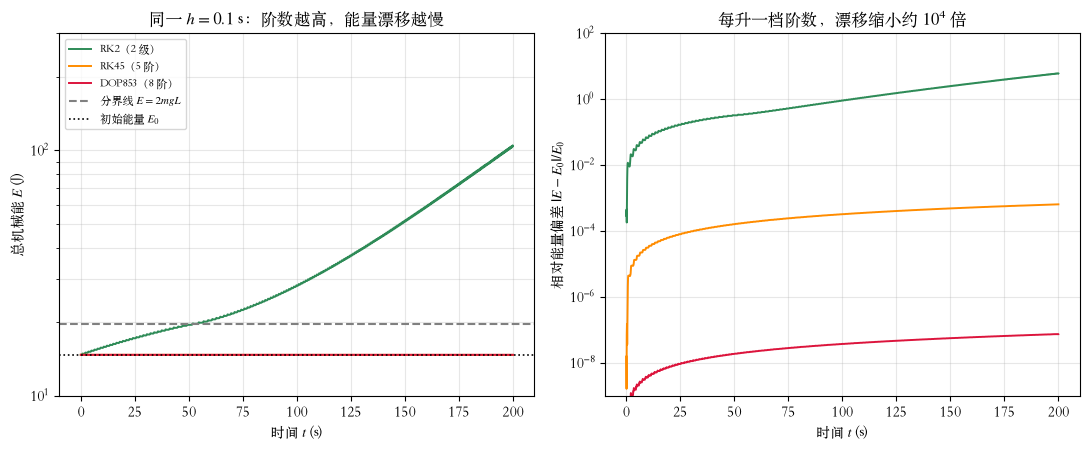

In [7]:
# scipy 高阶方法：RK45（Dormand–Prince 5 阶）与 DOP853（8 阶），步长上限锁在与 RK2 相同的 h_long
rhs = lambda t, y: [y[1], -(g / L) * np.sin(y[0])]

sol45 = solve_ivp(rhs, [0.0, t_long], [theta0, omega0], method='RK45',
                  rtol=1e-3, atol=1e-6, first_step=h_long, max_step=h_long)
sol853 = solve_ivp(rhs, [0.0, t_long], [theta0, omega0], method='DOP853',
                   rtol=1e-6, atol=1e-9, first_step=h_long, max_step=h_long)

for nm, sol in (('RK45', sol45), ('DOP853', sol853)):
    print(f'{nm}：接受 {len(sol.t) - 1} 步，步长全部 ≤ h_long = {h_long} s（2000 个整步 + 1 个收尾零头步）')

E45 = 0.5 * m * L**2 * sol45.y[1]**2 + m * g * L * (1 - np.cos(sol45.y[0]))
E853 = 0.5 * m * L**2 * sol853.y[1]**2 + m * g * L * (1 - np.cos(sol853.y[0]))

runs = [
    ('RK2（2 级）', t_L, E_rL, 'seagreen'),
    ('RK45（5 阶）', sol45.t, E45, 'darkorange'),
    ('DOP853（8 阶）', sol853.t, E853, 'crimson'),
]
print()
for name, t_ax, E_ax, color in runs:
    k = np.argmax(E_ax > E_sep) if (E_ax > E_sep).any() else -1
    cross = f't = {t_ax[k]:.1f} s 越过分界线' if k >= 0 else '200 s 内不越界'
    print(f'{name}：{cross}；E_末/E0 = {E_ax[-1] / E0:.6f}（相对漂移 {100 * (E_ax[-1] / E0 - 1):+.2e}%）')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))

# (a) 能量 vs 时间：三种阶数同台
for name, t_ax, E_ax, color in runs:
    ax1.semilogy(t_ax, E_ax, '-', lw=1.4, color=color, label=name)
ax1.axhline(E_sep, ls='--', color='gray', lw=1.5, label='分界线 $E = 2mgL$')
ax1.axhline(E0, ls=':', color='black', lw=1.2, label='初始能量 $E_0$')
ax1.set_ylim(10, 3e2)
ax1.set_xlabel('时间 $t$ (s)')
ax1.set_ylabel('总机械能 $E$ (J)')
ax1.set_title('同一 $h = 0.1$ s：阶数越高，能量漂移越慢')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(alpha=0.3, which='both')

# (b) 相对能量偏差 |E - E0| / E0
for name, t_ax, E_ax, color in runs:
    ax2.semilogy(t_ax[1:], np.abs(E_ax[1:] / E0 - 1), '-', lw=1.4, color=color)
ax2.set_ylim(1e-9, 1e2)
ax2.set_xlabel('时间 $t$ (s)')
ax2.set_ylabel('相对能量偏差 $|E - E_0|/E_0$')
ax2.set_title('每升一档阶数，漂移缩小约 $10^4$ 倍')
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig('outputs/5_simple_pendulum_rk2_highorder.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()


**读图**：

- **阶数一升，漂移坍缩**：末能量比 $E/E_0$：RK2 $7.08$（$51.7$ s 越过分界线）、RK45 $0.99935$、DOP853 $0.99999993$。漂移率（后半段线性拟合）：RK2 $+5.0\times 10^{-2}$/s、RK45 $-3.2\times 10^{-6}$/s、DOP853 $-3.7\times 10^{-10}$/s——每升一档阶数，漂移率缩小约 $10^4$ 倍。简谐振子可解析给出理论：漂移率 $\propto h^{p+1}$——RK2 $h^3$、RK45 $h^5$、DOP853 $h^9$。
- **方向也翻了**：RK2 持续**注**能，RK45 与 DOP853 却在缓慢**漏**能——每步能量比偏离 1 的首项符号为负，高阶方法的误差常往反方向走。
- **"看不见" ≠ "不存在"**：DOP853 的曲线纹丝不动，但漂移只是被压到 $10^{-7}$ 量级——依旧无界，只是把"越界"推远了千万倍以上。代价也明摆在级数里：RK2 每步 2 次右端、RK45 6 次（FSAL 复用一次）、DOP853 12 次。要能量长时间**有界**，靠的不是更高阶，而是更新格式本身的几何性质（辛方法，后续话题）。


## 结论与思考

**先对照引言的三个预测**（还精确吗？漂移快慢？减半比？），再记住几条：

- **RK2 = 用计算量换精度**：每步多算一次右端，换来周期误差 $\propto h^2$、能量漂移 $\propto h^3\,t$——同一步长下比欧拉好几个数量级，"撑得住"的时间约长 $h^2$ 倍。
- **"恰好精确"是常力的特例**：力随状态变化（$\sin\theta$）后，RK2 回到"二阶但漂移"的常态——这就是例 3 思考①的答案。
- **漂移不只是数字**：能量爬升把摆推过分界线，往复变旋转——数值误差改写了速度相空间的轨道结构。
- **无界是宿命，快慢是选择**：欧拉 $\propto h$、RK2 $\propto h^3$，减步长都能延缓，但都不能根除。要让能量长时间**有界**，需要更新格式本身具有更强的几何性质——这是后面话题的引子。
- **阶数是杠杆，不是解药**：换用 scipy 的 RK45 / DOP853（上一节），同一步长下漂移率被依次压小约 $10^4$ 倍——200 s 末的相对漂移从 RK2 的 $+608\%$ 缩到 DOP853 的 $-7.5\times 10^{-6}\%$；但被压小的漂移依旧无界，"越界"只是被推远。

**思考**：

1. 把长时间模拟的步长改为 $h = 0.05$ s 重跑上一节代码：RK2 的越界时间变为几倍？与漂移率 $\propto h^3$ 的预期一致吗？
2. 收敛性分析在小振幅（$10°$）下测了周期误差。把 $\theta_0$ 改为 $120°$（精确周期仍由椭圆积分给出）再测：RK2 的周期误差还是 $\propto h^2$ 吗？
3. 两种方法的线性化稳定界限都是 $h < 2\sqrt{L/g} \approx 0.64$ s。取 $h = 0.8$ 重跑主算例：会发生什么？稳定界限之内就一定"准"吗？
4. 把上一节的 `max_step` 改为 $h = 0.05$ s 重跑：RK2 与 RK45 的漂移率各变几倍？与 $\propto h^{p+1}$ 的预期一致吗？